<a href="https://colab.research.google.com/github/adnanmk-1999/Subpixel_Shift_CNN/blob/main/test_NN_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from pathlib import Path

In [7]:
IMG_HEIGHT  = 300
IMG_WIDTH = 363

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
test_dir = '/content/drive/MyDrive/Subpixel_Shift_CNN/test_dataset'

In [10]:
def parse_filename(fname):
    """Extract (shift_x, shift_y) from a filename like test_0.12915_1.22835.png"""
    stem = Path(fname).stem

    m = re.match(r'^test_(-?\d+\.\d+)_(-?\d+\.\d+)$', stem)

    if m:
        sx, sy = m.groups()
        return float(sx), float(sy)

    return None, None

def load_labels_from_dir(directory):
    """Return a DataFrame with filepath, shift_x, shift_y for every PNG in directory."""
    records = []
    for fpath in sorted(Path(directory).glob('*.png')):
        sx, sy = parse_filename(fpath.name)
        if sx is not None:
            records.append({'filepath': str(fpath), 'shift_x': sx, 'shift_y': sy})
    return pd.DataFrame(records)

In [11]:
test_df = load_labels_from_dir(test_dir)
total_test  = len(test_df)
print('Total test images      :', total_test)

Total test images      : 100


In [12]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Subpixel_Shift_CNN/subpixel_shift_model.keras')

--- PREDICTION RESULTS ---
File: test_1.15707_2.81428.png
True X Shift : 1.15707
Pred X Shift : 1.10232
-> X Error   : 0.05475 pixels

True Y Shift : 2.81428
Pred Y Shift : 2.78516
-> Y Error   : 0.02912 pixels


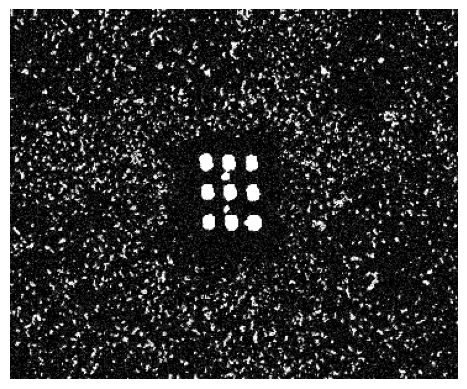

In [14]:
# 1. Grab one random row from your test dataframe
random_sample = test_df.sample(n=1).iloc[0]

img_path = random_sample['filepath']
true_x = random_sample['shift_x']
true_y = random_sample['shift_y']

# 2. Load and preprocess the image
# We use the IMG_HEIGHT (300) and IMG_WIDTH (363) you set earlier
img = tf.keras.utils.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = tf.keras.utils.img_to_array(img)
img_array = img_array / 255.0  # Crucial: apply the 1./255 scaling!

# 3. Add a "batch" dimension
# Keras models ALWAYS expect a batch. We change shape from (300, 363, 3) to (1, 300, 363, 3)
img_batch = np.expand_dims(img_array, axis=0)

# 4. Make the prediction!
prediction = model.predict(img_batch, verbose=0)
pred_x, pred_y = prediction[0]

# 5. Print the results
print("--- PREDICTION RESULTS ---")
print(f"File: {img_path.split('/')[-1]}")
print(f"True X Shift : {true_x:.5f}")
print(f"Pred X Shift : {pred_x:.5f}")
print(f"-> X Error   : {abs(true_x - pred_x):.5f} pixels\n")

print(f"True Y Shift : {true_y:.5f}")
print(f"Pred Y Shift : {pred_y:.5f}")
print(f"-> Y Error   : {abs(true_y - pred_y):.5f} pixels")

# Optional: Show the image just so you know what you're looking at
plt.imshow(img)
plt.axis('off')
plt.show()